<a href="https://colab.research.google.com/github/Jupiterian/ML-Learning-Portfolio/blob/main/pytorch/PyTorch_Revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
# Import pytorch and subclasses
import torch
import torch.nn as nn
import torch.optim as optim
# Import numpy and pandas
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [55]:
# Data Fetcher
import kagglehub
path = kagglehub.dataset_download("jayjoshi37/fifa-player-performance-and-market-value-analytics")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fifa-player-performance-and-market-value-analytics' dataset.
Path to dataset files: /kaggle/input/fifa-player-performance-and-market-value-analytics


In [56]:
# Load Data
df = pd.read_csv(f"{path}/fifa_player_performance_market_value.csv")
df.head()

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low


# Feature Extraction
Given that I have no experience or knowledge of NLP, I will be only using the numeric features from the dataset. The model will attempt to predict the ```overall_rating``` of a player given the ```age```, ```matches_played```, ```goals```, ```assists```, ```minutes_played```, and ```market_Value_million_eur```.


In [57]:
# Feature modification
injury_map = {'No': 0, 'Yes': 1}
transfer_map = {'Low': 0, 'Medium': 1, "High": 2}

df["injury_prone"] = df["injury_prone"].replace(injury_map)
df["transfer_risk_level"] = df["transfer_risk_level"].replace(transfer_map)

df.head()

/tmp/ipython-input-666852844.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["injury_prone"] = df["injury_prone"].replace(injury_map)
/tmp/ipython-input-666852844.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["transfer_risk_level"] = df["transfer_risk_level"].replace(transfer_map)


,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,0,0
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,0,2
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,0,1
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,1,1
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,0,0


In [58]:
# Data Setup
X = df[["age", "matches_played", "goals", "assists", "minutes_played", "market_value_million_eur"]]
y = df["overall_rating"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
class Classifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=6, out_features=12)
    self.layer2 = nn.ReLU()
    self.layer3 = nn.Linear(in_features=12, out_features=12)
    self.layer4 = nn.ReLU()
    self.layer5 = nn.Linear(in_features=12, out_features=1) # Corrected: in_features changed from 6 to 12
  def forward(self, x):
    return (self.layer5(self.layer4(self.layer3(self.layer2(self.layer1(x))))))

model = Classifier()

In [60]:
# Loss and Optimizer Functions
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.01) # Corrected: Specify Adam optimizer
loss_fn = nn.MSELoss()

In [61]:
# Convert data to PyTorch tensors
X_train = torch.from_numpy(X_train.values).float()
y_train = torch.from_numpy(y_train.values).float().reshape(-1, 1)
X_test = torch.from_numpy(X_test.values).float()
y_test = torch.from_numpy(y_test.values).float().reshape(-1, 1)

In [62]:
## Training Loop
epochs = 2001

for epoch in range(epochs):

  # 1. Training Mode
  model.train()

  # 2. Forward Pass
  y_pred = model(X_train)

  # 3. Loss
  loss = loss_fn(y_pred, y_train)

  # 4. Zero gradients
  optimizer.zero_grad()

  # 5. Backpropagation
  loss.backward()

  # 6. Step the optimizer
  optimizer.step()

  # 7. Evaluation
  if epoch%20 == 0:
      model.eval()
      # 1. Forward pass
      y_test_pred = model(X_test)
      # 2. Calculate test loss
      test_loss = loss_fn(y_test_pred,y_test)
      # Print out what's happening
      print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")

Epoch: 0 | Train loss: 42822.414 | Test loss: 30202.979
Epoch: 20 | Train loss: 1235.102 | Test loss: 1258.631
Epoch: 40 | Train loss: 475.309 | Test loss: 490.953
Epoch: 60 | Train loss: 341.514 | Test loss: 344.243
Epoch: 80 | Train loss: 298.846 | Test loss: 295.370
Epoch: 100 | Train loss: 272.981 | Test loss: 266.618
Epoch: 120 | Train loss: 250.616 | Test loss: 244.857
Epoch: 140 | Train loss: 242.808 | Test loss: 237.196
Epoch: 160 | Train loss: 238.660 | Test loss: 232.511
Epoch: 180 | Train loss: 236.343 | Test loss: 230.297
Epoch: 200 | Train loss: 235.042 | Test loss: 229.954
Epoch: 220 | Train loss: 235.619 | Test loss: 225.708
Epoch: 240 | Train loss: 232.352 | Test loss: 224.811
Epoch: 260 | Train loss: 231.113 | Test loss: 223.529
Epoch: 280 | Train loss: 230.630 | Test loss: 226.538
Epoch: 300 | Train loss: 228.990 | Test loss: 224.789
Epoch: 320 | Train loss: 231.156 | Test loss: 229.063
Epoch: 340 | Train loss: 226.046 | Test loss: 218.233
Epoch: 360 | Train loss: 224

In [63]:
# Final Performance
model.eval()
with torch.inference_mode():
    predictions = model(X_train)
    predictions_test = model(X_test)

Final Test Mean Squared Error (MSE): 191.916
R-squared (R2) Score on Test Set: -1.052


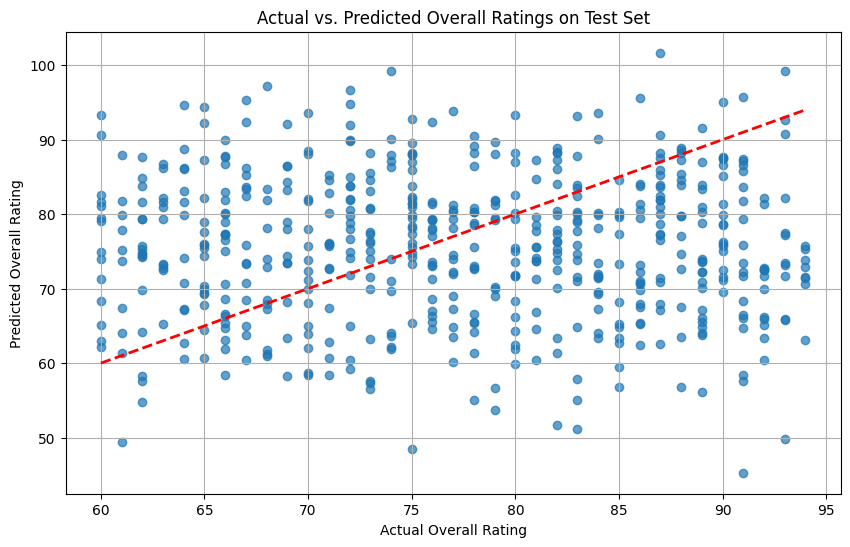

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Convert predictions and actual values to numpy for plotting and sklearn metrics
predictions_test_np = predictions_test.cpu().numpy()
y_test_np = y_test.cpu().numpy()

# Calculate final Test MSE (which is your loss function)
final_test_mse = loss_fn(predictions_test, y_test).item()
print(f"Final Test Mean Squared Error (MSE): {final_test_mse:.3f}")

# Calculate R-squared score
r2 = r2_score(y_test_np, predictions_test_np)
print(f"R-squared (R2) Score on Test Set: {r2:.3f}")

# Visualization: Scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_np, predictions_test_np, alpha=0.7)
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--', lw=2) # y=x line
plt.xlabel("Actual Overall Rating")
plt.ylabel("Predicted Overall Rating")
plt.title("Actual vs. Predicted Overall Ratings on Test Set")
plt.grid(True)
plt.show()